# Molecular GNN Benchmark Notebook

This notebook compares three GNN-based models for molecular learning:

- CGCNN-style baseline using `CGConv`
- SchNet
- DimeNet

It supports two dataset modes:

- **QM9** for scalar molecular property prediction
- **MD17** for molecular energy prediction, with optional force supervision/evaluation

Use this notebook to train, evaluate, and compare the models, then generate plots and CSV summaries.

## Imports and core utilities

In [4]:
# Optional: install dependencies in a fresh environment
# Uncomment and run this cell if needed.

%pip install -r requirements.txt


  Using cached torch_geometric-2.7.0-py3-none-any.whl.metadata (63 kB)
Using cached torch_geometric-2.7.0-py3-none-any.whl (1.3 MB)


In [6]:
import torch

# Function to format the PyTorch version string (e.g., "2.4.0+cu121" -> "2.4.0")
def format_pytorch_version(version):
    return version.split('+')[0]

# Get the current PyTorch version
TORCH_version = torch.__version__
TORCH = format_pytorch_version(TORCH_version)

# Function to format the CUDA version string (e.g., "12.1" -> "cu121")
def format_cuda_version(version):
    if version is None:
        return 'cpu' # Fallback to CPU if CUDA is not available
    return 'cu' + version.replace('.', '')

# Get the current CUDA version
CUDA_version = torch.version.cuda
CUDA = format_cuda_version(CUDA_version)

print(f"Torch version: {TORCH}, CUDA version: {CUDA}")

# Install torch-cluster using the determined versions
!pip install torch-cluster -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html

# (Optional, but often needed) Install other PyG dependencies and PyTorch Geometric itself
!pip install torch-scatter -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-geometric

Torch version: 2.10.0, CUDA version: cu128
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 40.7 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 122.9 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 55.7 MB/s eta 0:00:00


In [7]:
from __future__ import annotations

import copy
import json
import random
import time
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.datasets import QM9, MD17
from torch_geometric.loader import DataLoader
from torch_geometric.nn import CGConv, DimeNet, SchNet, global_mean_pool, radius_graph


In [8]:
QM9_TARGET_NAMES = {
    0: "mu",
    1: "alpha",
    2: "homo",
    3: "lumo",
    4: "gap",
    5: "r2",
    6: "zpve",
    7: "U0",
    8: "U",
    9: "H",
    10: "G",
    11: "Cv",
    12: "U0_atom",
    13: "U_atom",
    14: "H_atom",
    15: "G_atom",
    16: "A",
    17: "B",
    18: "C",
}

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def infer_device(device_arg: str) -> torch.device:
    if device_arg == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(device_arg)

def safe_rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

@dataclass
class RunConfig:
    dataset: str = "qm9"                  # "qm9" or "md17"
    dataset_root: str = "./data"
    output_dir: str = "./outputs_molecular_benchmark"
    seed: int = 42
    device: str = "auto"
    batch_size: int = 32
    epochs: int = 30
    lr: float = 1e-3
    weight_decay: float = 1e-6
    patience: int = 8
    num_workers: int = 0
    max_samples: Optional[int] = 5000
    train_ratio: float = 0.8
    val_ratio: float = 0.1
    cutoff: float = 5.0
    use_forces: bool = False
    force_weight: float = 10.0
    qm9_target_index: int = 4            # 4 = gap
    md17_molecule: str = "revised aspirin"


## Choose your run configuration

You can switch between:

- `dataset="qm9"` for molecular scalar properties
- `dataset="md17"` for molecular energies, and optionally forces

In [9]:
# Edit this configuration before running the next cells
cfg = RunConfig(
    dataset="qm9",              # "qm9" or "md17"
    dataset_root="./data",
    output_dir="./outputs_molecular_benchmark",
    seed=42,
    device="auto",
    batch_size=32,
    epochs=30,
    lr=1e-3,
    weight_decay=1e-6,
    patience=8,
    num_workers=0,
    max_samples=5000,
    train_ratio=0.8,
    val_ratio=0.1,
    cutoff=5.0,
    use_forces=False,           # set True for MD17 energy+forces
    force_weight=10.0,
    qm9_target_index=4,         # QM9: 4 = gap
    md17_molecule="revised aspirin",
)

set_seed(cfg.seed)
device = infer_device(cfg.device)
out_dir = Path(cfg.output_dir)
out_dir.mkdir(parents=True, exist_ok=True)

print("Using device:", device)
print(json.dumps(asdict(cfg), indent=2))


Using device: cuda
{
  "dataset": "qm9",
  "dataset_root": "./data",
  "output_dir": "./outputs_molecular_benchmark",
  "seed": 42,
  "device": "auto",
  "batch_size": 32,
  "epochs": 30,
  "lr": 0.001,
  "weight_decay": 1e-06,
  "patience": 8,
  "num_workers": 0,
  "max_samples": 5000,
  "train_ratio": 0.8,
  "val_ratio": 0.1,
  "cutoff": 5.0,
  "use_forces": false,
  "force_weight": 10.0,
  "qm9_target_index": 4,
  "md17_molecule": "revised aspirin"
}


## Dataset preparation helpers

In [10]:
def split_list(data_list, train_ratio=0.8, val_ratio=0.1, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(data_list))
    rng.shuffle(idx)

    n = len(idx)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train+n_val]
    test_idx = idx[n_train+n_val:]

    train_set = [data_list[i] for i in train_idx]
    val_set = [data_list[i] for i in val_idx]
    test_set = [data_list[i] for i in test_idx]
    return train_set, val_set, test_set

def compute_scalar_stats(dataset, attr="y"):
    vals = []
    for d in dataset:
        x = getattr(d, attr)
        vals.append(x.view(-1).float())
    vals = torch.cat(vals, dim=0)
    mean = vals.mean().item()
    std = vals.std().item()
    if std < 1e-12:
        std = 1.0
    return mean, std

def standardize_attr(dataset, attr: str, mean: float, std: float):
    out = []
    for d in dataset:
        d2 = copy.copy(d)
        setattr(d2, attr, (getattr(d2, attr).float() - mean) / std)
        out.append(d2)
    return out

def prepare_qm9(cfg: RunConfig):
    raw = QM9(root=cfg.dataset_root)
    data_list = []
    for d in raw:
        d2 = copy.copy(d)
        d2.y = d.y[:, cfg.qm9_target_index].view(-1)
        data_list.append(d2)

    if cfg.max_samples is not None:
        data_list = data_list[:cfg.max_samples]

    train_set, val_set, test_set = split_list(
        data_list, train_ratio=cfg.train_ratio, val_ratio=cfg.val_ratio, seed=cfg.seed
    )

    y_mean, y_std = compute_scalar_stats(train_set, attr="y")
    train_set = standardize_attr(train_set, "y", y_mean, y_std)
    val_set = standardize_attr(val_set, "y", y_mean, y_std)
    test_set = standardize_attr(test_set, "y", y_mean, y_std)

    stats = {"y_mean": y_mean, "y_std": y_std, "f_mean": None, "f_std": None}
    meta = {
        "dataset_name": "QM9",
        "target_name": QM9_TARGET_NAMES.get(cfg.qm9_target_index, str(cfg.qm9_target_index)),
        "target_type": "scalar_property",
    }
    return train_set, val_set, test_set, stats, meta

def prepare_md17(cfg: RunConfig):
    raw = MD17(root=cfg.dataset_root, name=cfg.md17_molecule)

    data_list = [copy.copy(d) for d in raw]
    if cfg.max_samples is not None:
        data_list = data_list[:cfg.max_samples]

    train_set, val_set, test_set = split_list(
        data_list, train_ratio=cfg.train_ratio, val_ratio=cfg.val_ratio, seed=cfg.seed
    )

    y_mean, y_std = compute_scalar_stats(train_set, attr="energy")
    train_set = standardize_attr(train_set, "energy", y_mean, y_std)
    val_set = standardize_attr(val_set, "energy", y_mean, y_std)
    test_set = standardize_attr(test_set, "energy", y_mean, y_std)

    if cfg.use_forces:
        all_f = torch.cat([d.force.view(-1) for d in train_set], dim=0).float()
        f_mean = all_f.mean().item()
        f_std = all_f.std().item()
        if f_std < 1e-12:
            f_std = 1.0

        def standardize_force(ds):
            out = []
            for d in ds:
                d2 = copy.copy(d)
                d2.force = (d2.force.float() - f_mean) / f_std
                out.append(d2)
            return out

        train_set = standardize_force(train_set)
        val_set = standardize_force(val_set)
        test_set = standardize_force(test_set)
    else:
        f_mean, f_std = None, None

    stats = {"y_mean": y_mean, "y_std": y_std, "f_mean": f_mean, "f_std": f_std}
    meta = {
        "dataset_name": "MD17",
        "target_name": cfg.md17_molecule,
        "target_type": "energy" if not cfg.use_forces else "energy_and_forces",
    }
    return train_set, val_set, test_set, stats, meta


## Load the dataset

In [11]:
if cfg.dataset == "qm9":
    train_set, val_set, test_set, stats, meta = prepare_qm9(cfg)
else:
    train_set, val_set, test_set, stats, meta = prepare_md17(cfg)

train_loader = DataLoader(train_set, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
val_loader = DataLoader(val_set, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
test_loader = DataLoader(test_set, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

print("Dataset meta:")
print(json.dumps(meta, indent=2))
print(f"Train/Val/Test sizes: {len(train_set)}, {len(val_set)}, {len(test_set)}")


Extracting data/raw/qm9_v3.zip
Processing...
Using a pre-processed version of the dataset. Please install 'rdkit' to alternatively process the raw data.
Done!


Dataset meta:
{
  "dataset_name": "QM9",
  "target_name": "gap",
  "target_type": "scalar_property"
}
Train/Val/Test sizes: 4000, 500, 500


## Model definitions

In [12]:
class CGCNNStyle(nn.Module):
    def __init__(self, emb_dim=128, num_layers=4, cutoff=5.0, dropout=0.0):
        super().__init__()
        self.cutoff = cutoff
        self.embedding = nn.Embedding(100, emb_dim)
        self.convs = nn.ModuleList([
            CGConv(channels=emb_dim, dim=1, batch_norm=True)
            for _ in range(num_layers)
        ])
        self.norms = nn.ModuleList([nn.BatchNorm1d(emb_dim) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, 1),
        )

    def forward(self, z, pos, batch):
        x = self.embedding(z)
        edge_index = radius_graph(pos, r=self.cutoff, batch=batch, loop=False, max_num_neighbors=64)
        row, col = edge_index
        dist = (pos[row] - pos[col]).norm(dim=-1, keepdim=True)

        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, edge_index, dist)
            x = norm(x)
            x = F.relu(x)
            x = self.dropout(x)

        g = global_mean_pool(x, batch)
        return self.head(g).view(-1)

class SchNetWrapper(nn.Module):
    def __init__(self, cutoff=10.0):
        super().__init__()
        self.model = SchNet(
            hidden_channels=128,
            num_filters=128,
            num_interactions=6,
            num_gaussians=50,
            cutoff=cutoff,
            readout='add',
            dipole=False,
        )

    def forward(self, z, pos, batch):
        return self.model(z=z, pos=pos, batch=batch).view(-1)

class DimeNetWrapper(nn.Module):
    def __init__(self, cutoff=5.0):
        super().__init__()
        self.model = DimeNet(
            hidden_channels=128,
            out_channels=1,
            num_blocks=4,
            num_bilinear=8,
            num_spherical=7,
            num_radial=6,
            cutoff=cutoff,
            max_num_neighbors=64,
        )

    def forward(self, z, pos, batch):
        return self.model(z=z, pos=pos, batch=batch).view(-1)

def build_model(name: str, cutoff: float):
    if name == "cgcnn":
        return CGCNNStyle(cutoff=cutoff)
    if name == "schnet":
        return SchNetWrapper(cutoff=max(cutoff, 10.0))
    if name == "dimenet":
        return DimeNetWrapper(cutoff=cutoff)
    raise ValueError(f"Unknown model: {name}")


## Training and evaluation helpers

In [13]:
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": safe_rmse(y_true, y_pred),
        "r2": float(r2_score(y_true, y_pred)),
    }

def forward_energy_and_forces(model, batch, use_forces: bool):
    if use_forces:
        pos = batch.pos.clone().detach().requires_grad_(True)
    else:
        pos = batch.pos

    energy = model(batch.z, pos, batch.batch)

    if use_forces:
        grad = torch.autograd.grad(
            outputs=energy.sum(),
            inputs=pos,
            create_graph=True,
            retain_graph=True,
            allow_unused=False,
        )[0]
        force_pred = -grad
        return energy, force_pred

    return energy, None

def train_one_epoch_qm9(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_items = 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad(set_to_none=True)
        pred = model(batch.z, batch.pos, batch.batch)
        target = batch.y.view(-1)
        loss = F.mse_loss(pred, target)
        loss.backward()
        optimizer.step()

        n = target.numel()
        total_loss += loss.item() * n
        total_items += n

    return total_loss / max(total_items, 1)

def train_one_epoch_md17(model, loader, optimizer, device, use_forces: bool, force_weight: float):
    model.train()
    total_loss = 0.0
    total_items = 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad(set_to_none=True)

        energy_pred, force_pred = forward_energy_and_forces(model, batch, use_forces=use_forces)
        energy_true = batch.energy.view(-1)

        loss_e = F.mse_loss(energy_pred, energy_true)
        if use_forces:
            loss_f = F.mse_loss(force_pred, batch.force)
            loss = loss_e + force_weight * loss_f
        else:
            loss = loss_e

        loss.backward()
        optimizer.step()

        n = energy_true.numel()
        total_loss += loss.item() * n
        total_items += n

    return total_loss / max(total_items, 1)

@torch.no_grad()
def evaluate_qm9(model, loader, device, y_mean, y_std):
    model.eval()
    all_pred, all_true = [], []
    num_graphs = 0
    start = time.perf_counter()

    for batch in loader:
        batch = batch.to(device)
        pred = model(batch.z, batch.pos, batch.batch)
        target = batch.y.view(-1)

        pred_real = pred * y_std + y_mean
        target_real = target * y_std + y_mean

        all_pred.append(pred_real.cpu())
        all_true.append(target_real.cpu())
        num_graphs += batch.num_graphs

    elapsed = time.perf_counter() - start
    y_pred = torch.cat(all_pred).numpy()
    y_true = torch.cat(all_true).numpy()

    m = regression_metrics(y_true, y_pred)
    m["latency_ms_per_graph"] = (elapsed / max(num_graphs, 1)) * 1000.0
    return m

def evaluate_md17(model, loader, device, y_mean, y_std, use_forces, f_mean, f_std):
    model.eval()
    all_e_pred, all_e_true = [], []
    all_f_pred, all_f_true = [], []
    num_graphs = 0
    start = time.perf_counter()

    for batch in loader:
        batch = batch.to(device)
        with torch.enable_grad():
            energy_pred, force_pred = forward_energy_and_forces(model, batch, use_forces=use_forces)

        energy_true = batch.energy.view(-1)
        energy_pred_real = energy_pred * y_std + y_mean
        energy_true_real = energy_true * y_std + y_mean

        all_e_pred.append(energy_pred_real.detach().cpu())
        all_e_true.append(energy_true_real.detach().cpu())

        if use_forces:
            force_pred_real = force_pred * f_std + f_mean
            force_true_real = batch.force * f_std + f_mean
            all_f_pred.append(force_pred_real.detach().cpu().view(-1))
            all_f_true.append(force_true_real.detach().cpu().view(-1))

        num_graphs += batch.num_graphs

    elapsed = time.perf_counter() - start

    e_pred = torch.cat(all_e_pred).numpy()
    e_true = torch.cat(all_e_true).numpy()
    m_e = regression_metrics(e_true, e_pred)
    m_e["latency_ms_per_graph"] = (elapsed / max(num_graphs, 1)) * 1000.0

    if use_forces:
        f_pred = torch.cat(all_f_pred).numpy()
        f_true = torch.cat(all_f_true).numpy()
        m_f = regression_metrics(f_true, f_pred)
        return {
            "energy_mae": m_e["mae"],
            "energy_rmse": m_e["rmse"],
            "energy_r2": m_e["r2"],
            "force_mae": m_f["mae"],
            "force_rmse": m_f["rmse"],
            "force_r2": m_f["r2"],
            "latency_ms_per_graph": m_e["latency_ms_per_graph"],
        }

    return {
        "energy_mae": m_e["mae"],
        "energy_rmse": m_e["rmse"],
        "energy_r2": m_e["r2"],
        "latency_ms_per_graph": m_e["latency_ms_per_graph"],
    }

def train_model(cfg: RunConfig, model_name: str, train_loader, val_loader, test_loader, stats):
    device = infer_device(cfg.device)
    model = build_model(model_name, cfg.cutoff).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.7, patience=3)

    best_state = None
    best_key = float("inf")
    bad_epochs = 0
    history = []

    t0 = time.perf_counter()

    for epoch in range(1, cfg.epochs + 1):
        if cfg.dataset == "qm9":
            train_loss = train_one_epoch_qm9(model, train_loader, optimizer, device)
            val_metrics = evaluate_qm9(model, val_loader, device, stats["y_mean"], stats["y_std"])
            test_metrics = evaluate_qm9(model, test_loader, device, stats["y_mean"], stats["y_std"])
            val_score = val_metrics["mae"]
        else:
            train_loss = train_one_epoch_md17(
                model, train_loader, optimizer, device,
                use_forces=cfg.use_forces, force_weight=cfg.force_weight
            )
            val_metrics = evaluate_md17(
                model, val_loader, device,
                stats["y_mean"], stats["y_std"], cfg.use_forces, stats["f_mean"], stats["f_std"]
            )
            test_metrics = evaluate_md17(
                model, test_loader, device,
                stats["y_mean"], stats["y_std"], cfg.use_forces, stats["f_mean"], stats["f_std"]
            )
            val_score = val_metrics["energy_mae"]

        scheduler.step(val_score)

        row = {
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "lr": optimizer.param_groups[0]["lr"],
        }
        row.update({f"val_{k}": v for k, v in val_metrics.items()})
        row.update({f"test_{k}": v for k, v in test_metrics.items()})
        history.append(row)

        if val_score < best_key:
            best_key = val_score
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        print(f"[{cfg.dataset}/{model_name}] Epoch {epoch:03d} | TrainLoss={train_loss:.5f} | BestValKey={best_key:.5f}")

        if bad_epochs >= cfg.patience:
            print(f"[{cfg.dataset}/{model_name}] Early stopping at epoch {epoch}")
            break

    train_time_sec = time.perf_counter() - t0
    model.load_state_dict(best_state)

    if cfg.dataset == "qm9":
        final_val = evaluate_qm9(model, val_loader, device, stats["y_mean"], stats["y_std"])
        final_test = evaluate_qm9(model, test_loader, device, stats["y_mean"], stats["y_std"])
        summary = {
            "model": model_name,
            "num_parameters": count_parameters(model),
            "train_time_sec": train_time_sec,
            "best_val_mae": final_val["mae"],
            "test_mae": final_test["mae"],
            "test_rmse": final_test["rmse"],
            "test_r2": final_test["r2"],
            "latency_ms_per_graph": final_test["latency_ms_per_graph"],
        }
    else:
        final_val = evaluate_md17(
            model, val_loader, device,
            stats["y_mean"], stats["y_std"], cfg.use_forces, stats["f_mean"], stats["f_std"]
        )
        final_test = evaluate_md17(
            model, test_loader, device,
            stats["y_mean"], stats["y_std"], cfg.use_forces, stats["f_mean"], stats["f_std"]
        )
        summary = {
            "model": model_name,
            "num_parameters": count_parameters(model),
            "train_time_sec": train_time_sec,
            "best_val_energy_mae": final_val["energy_mae"],
            "test_energy_mae": final_test["energy_mae"],
            "test_energy_rmse": final_test["energy_rmse"],
            "test_energy_r2": final_test["energy_r2"],
            "latency_ms_per_graph": final_test["latency_ms_per_graph"],
        }
        if cfg.use_forces:
            summary["test_force_mae"] = final_test["force_mae"]
            summary["test_force_rmse"] = final_test["force_rmse"]
            summary["test_force_r2"] = final_test["force_r2"]

    return model, history, summary


## Plotting helpers

In [14]:
def plot_history(history_df: pd.DataFrame, cfg: RunConfig, out_dir: Path):
    plt.figure(figsize=(10, 6))
    if cfg.dataset == "qm9":
        for name, sub in history_df.groupby("model"):
            plt.plot(sub["epoch"], sub["val_mae"], label=f"{name} val")
            plt.plot(sub["epoch"], sub["test_mae"], linestyle="--", label=f"{name} test")
        plt.ylabel("MAE")
        plt.title("QM9 learning curves")
        filename = "learning_curve_mae.png"
    else:
        for name, sub in history_df.groupby("model"):
            plt.plot(sub["epoch"], sub["val_energy_mae"], label=f"{name} val energy")
            plt.plot(sub["epoch"], sub["test_energy_mae"], linestyle="--", label=f"{name} test energy")
        plt.ylabel("Energy MAE")
        plt.title("MD17 learning curves")
        filename = "learning_curve_energy_mae.png"

    plt.xlabel("Epoch")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / filename, dpi=200)
    plt.show()

def plot_summary(summary_df: pd.DataFrame, cfg: RunConfig, out_dir: Path):
    if cfg.dataset == "qm9":
        metrics = ["test_mae", "test_rmse", "test_r2", "train_time_sec", "latency_ms_per_graph"]
    else:
        metrics = ["test_energy_mae", "test_energy_rmse", "test_energy_r2", "train_time_sec", "latency_ms_per_graph"]
        if cfg.use_forces and "test_force_mae" in summary_df.columns:
            metrics += ["test_force_mae", "test_force_rmse", "test_force_r2"]

    for metric in metrics:
        plt.figure(figsize=(8, 5))
        plt.bar(summary_df["model"], summary_df[metric])
        plt.ylabel(metric)
        plt.title(f"Model comparison: {metric}")
        plt.tight_layout()
        plt.savefig(out_dir / f"{metric}.png", dpi=200)
        plt.show()


## Train all three models

In [15]:
histories = []
summaries = []

for model_name in ["cgcnn", "schnet", "dimenet"]:
    model, history, summary = train_model(cfg, model_name, train_loader, val_loader, test_loader, stats)
    histories.extend(history)
    summaries.append(summary)
    torch.save(model.state_dict(), out_dir / f"{cfg.dataset}_{model_name}_best.pt")

history_df = pd.DataFrame(histories)
summary_df = pd.DataFrame(summaries)

sort_col = "test_mae" if cfg.dataset == "qm9" else "test_energy_mae"
summary_df = summary_df.sort_values(sort_col, ascending=True)

history_df.to_csv(out_dir / "epoch_metrics.csv", index=False)
summary_df.to_csv(out_dir / "metrics_summary.csv", index=False)

with open(out_dir / "run_config.json", "w", encoding="utf-8") as f:
    json.dump(asdict(cfg), f, indent=2)
with open(out_dir / "dataset_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print("Training complete.")
print(summary_df)


[qm9/cgcnn] Epoch 001 | TrainLoss=0.51007 | BestValKey=0.75038
[qm9/cgcnn] Epoch 002 | TrainLoss=0.43915 | BestValKey=0.73193
[qm9/cgcnn] Epoch 003 | TrainLoss=0.38062 | BestValKey=0.73193
[qm9/cgcnn] Epoch 004 | TrainLoss=0.34208 | BestValKey=0.73193
[qm9/cgcnn] Epoch 005 | TrainLoss=0.31382 | BestValKey=0.73193
[qm9/cgcnn] Epoch 006 | TrainLoss=0.30367 | BestValKey=0.57917
[qm9/cgcnn] Epoch 007 | TrainLoss=0.26932 | BestValKey=0.57917
[qm9/cgcnn] Epoch 008 | TrainLoss=0.23720 | BestValKey=0.55694
[qm9/cgcnn] Epoch 009 | TrainLoss=0.21420 | BestValKey=0.55694
[qm9/cgcnn] Epoch 010 | TrainLoss=0.21249 | BestValKey=0.55694
[qm9/cgcnn] Epoch 011 | TrainLoss=0.19470 | BestValKey=0.47895
[qm9/cgcnn] Epoch 012 | TrainLoss=0.19268 | BestValKey=0.47895
[qm9/cgcnn] Epoch 013 | TrainLoss=0.15793 | BestValKey=0.47895
[qm9/cgcnn] Epoch 014 | TrainLoss=0.15487 | BestValKey=0.46381
[qm9/cgcnn] Epoch 015 | TrainLoss=0.14214 | BestValKey=0.46381
[qm9/cgcnn] Epoch 016 | TrainLoss=0.13172 | BestValKey=

## Plot results

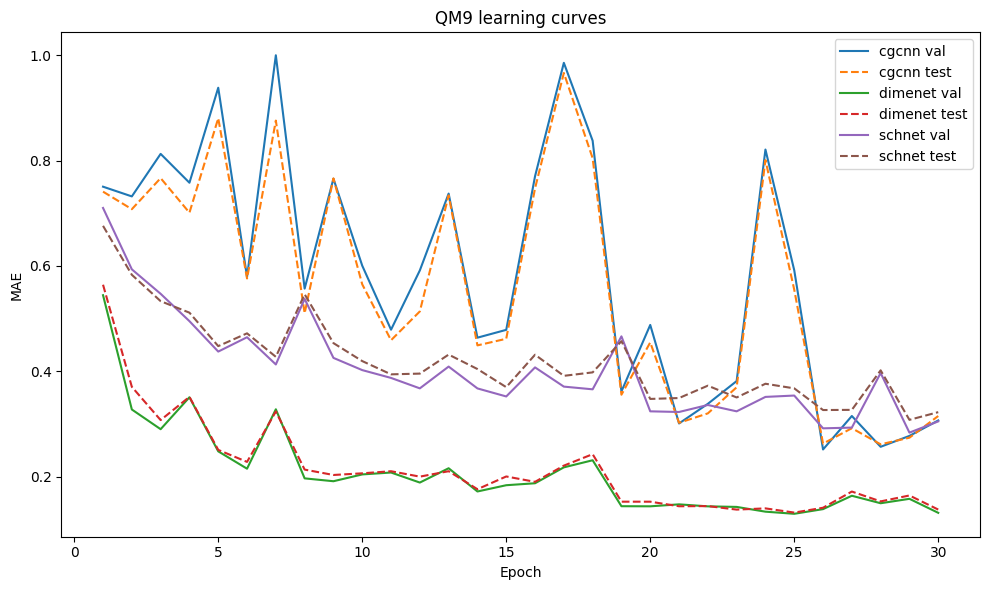

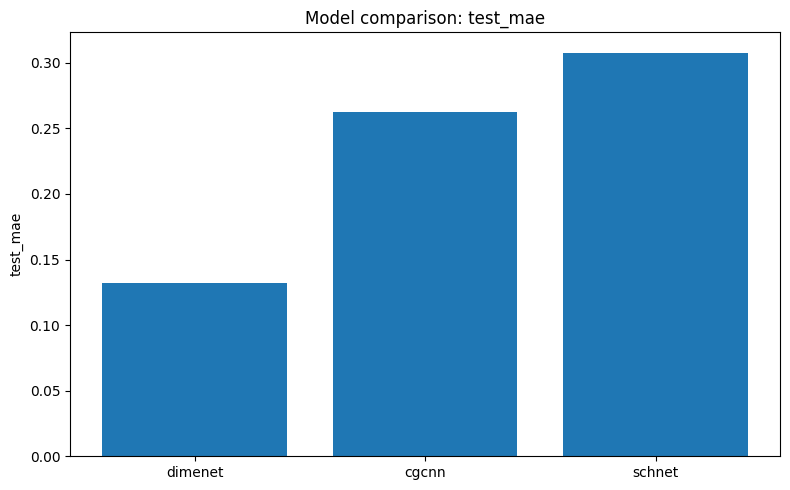

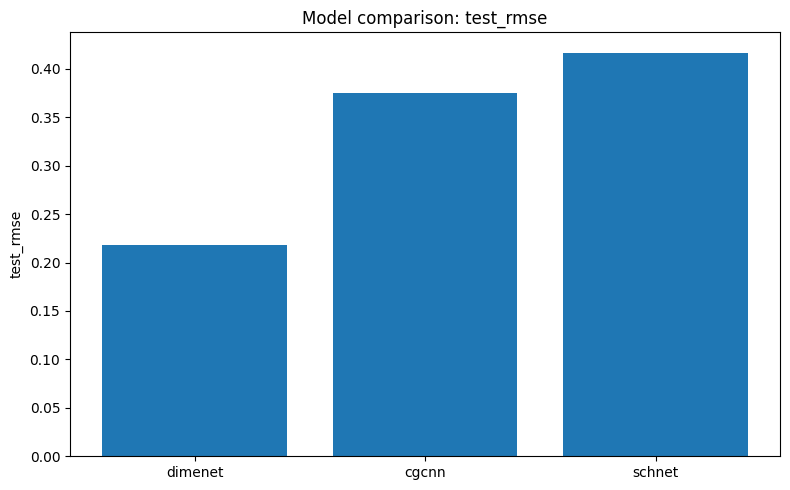

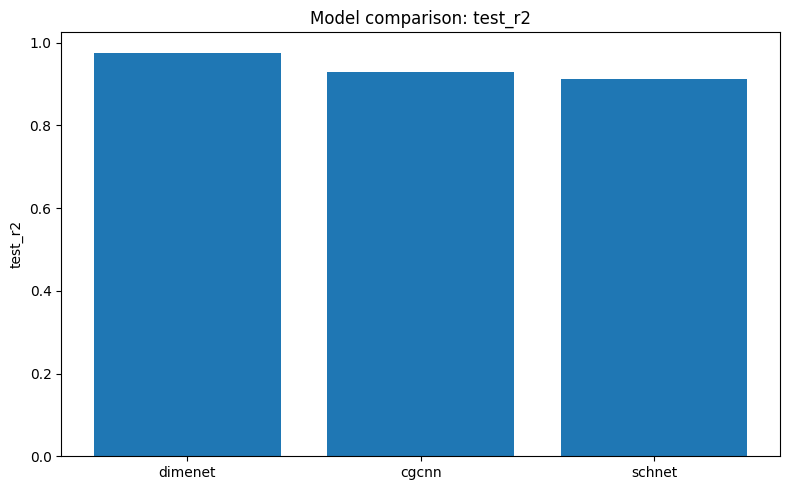

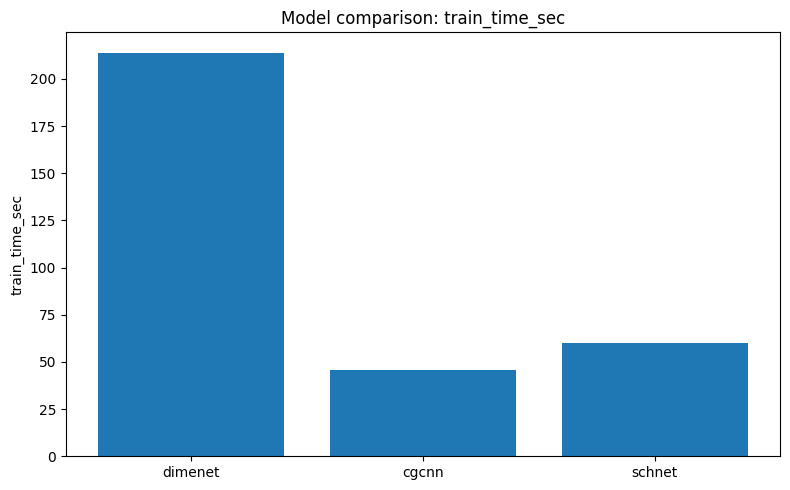

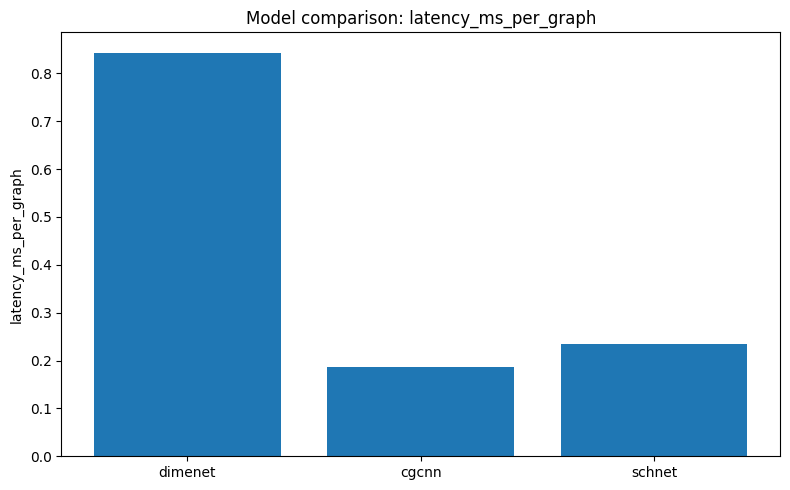

In [16]:
plot_history(history_df, cfg, out_dir)
plot_summary(summary_df, cfg, out_dir)


In [17]:
!zip -r outputs_molecular_benchmark.zip outputs_molecular_benchmark/

  adding: outputs_molecular_benchmark/ (stored 0%)
  adding: outputs_molecular_benchmark/metrics_summary.csv (deflated 39%)
  adding: outputs_molecular_benchmark/run_config.json (deflated 44%)
  adding: outputs_molecular_benchmark/test_r2.png (deflated 31%)
  adding: outputs_molecular_benchmark/dataset_meta.json (deflated 28%)
  adding: outputs_molecular_benchmark/test_mae.png (deflated 30%)
  adding: outputs_molecular_benchmark/test_rmse.png (deflated 29%)
  adding: outputs_molecular_benchmark/qm9_schnet_best.pt (deflated 8%)
  adding: outputs_molecular_benchmark/train_time_sec.png (deflated 28%)
  adding: outputs_molecular_benchmark/latency_ms_per_graph.png (deflated 27%)
  adding: outputs_molecular_benchmark/epoch_metrics.csv (deflated 53%)
  adding: outputs_molecular_benchmark/learning_curve_mae.png (deflated 4%)
  adding: outputs_molecular_benchmark/qm9_cgcnn_best.pt (deflated 8%)
  adding: outputs_molecular_benchmark/qm9_dimenet_best.pt (deflated 8%)


## Optional quick-start examples

### QM9
```python
cfg.dataset = "qm9"
cfg.qm9_target_index = 4
cfg.use_forces = False
cfg.max_samples = 5000
cfg.batch_size = 32
```

### MD17 energy only
```python
cfg.dataset = "md17"
cfg.md17_molecule = "revised aspirin"
cfg.use_forces = False
cfg.max_samples = 1000
cfg.batch_size = 16
```

### MD17 energy + forces
```python
cfg.dataset = "md17"
cfg.md17_molecule = "revised aspirin"
cfg.use_forces = True
cfg.force_weight = 10.0
cfg.max_samples = 1000
cfg.batch_size = 8
```